### Objective
Find out the demand for ambulances per hectare of Penang

Important data points: 
- Enroute timing and location (Ambulance start location)
- At Scene timing and location (Ambulance stopped location)
- At Patient timing and location (Paramedics reached patient)
- At Destination timing and location (Reached Hospital)
- Ready to Respond timing and location (When paramedics pressed the button to indicate they are ready to respond again) May not be accurate

Less important:
- Transporting timing and location (Detected location may not be accurate)

Penang's Max and Min coordinates:
- Latitude Min: 5.12
- Latitude Max: 5.585
- Longitude Min: 100.175
- Longitude Max: 100.551

### Getting map data from openstreetmaps

Download malaysia map from here: https://download.geofabrik.de/asia/malaysia-singapore-brunei.html#

Get the polygons for Penang. OSM id for Penang found by quering a location in Penang and looking at Adminstrative Boundary (Level 4)
`curl -L -o penang.poly "https://polygons.openstreetmap.fr/get_poly.py?id=4445131"`

Then extract penang from the OSM file.
`osmium extract -p penang.poly -s complete_ways --overwrite -o penang.osm.pbf malaysia-singapore-brunei-250101.osm.pbf`

find out how many rows with invalid data


In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import numpy as np
from geopy.distance import geodesic

In [2]:
import os
import sys
# print(gpd.__version__)
print(os.getcwd())

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/src


#### Directory structure
Obtained by running the `tree` command 

tree ../\<directory\>

```text
../penang_ambulance
├── datasets
│   ├── Processed_EMS_Calls_Penang_2024.csv
│   ├── Processed_EMS_Calls_Penang_2024.xlsx
│   ├── penang_maps
│   │   ├── penang_split
└── src
    ├── ems_data_wrangling.ipynb
    ├── helper_functions
    │   ├── __pycache__
    │   │   ├── helper_methods.cpython-39.pyc
    │   │   └── sql_connection_functions.cpython-39.pyc
    │   ├── helper_methods.py
    │   ├── querying_postgresql.py
    │   └── sql_connection_functions.py
```

#### The multipolygons of Penang is obtained via the following steps

Used http://nominatim.openstreetmap.org/ to get the OSM id of Penang, George town and Seberang Peria, which will allow me to get their .poly files

Working in the `datasets/penang_maps` directory

First obtain the whole map of Penang
```
curl -L -o penang.poly "https://polygons.openstreetmap.fr/get_poly.py?id=4445131"
osmium extract -p penang.poly -s complete_ways --overwrite -o penang.osm.pbf malaysia-singapore-brunei-250101.osm.pbf
ogr2ogr -f GPKG penang.gpkg penang.osm.pbf
ogr2ogr -f GPKG penang_3375.gpkg penang.gpkg -t_srs EPSG:3375 
ogr2ogr -f GPKG penang_split/penang_multipolygons.gpkg penang_3375.gpkg multipolygons
```

Penang is split into 2, george town and seberang perai

1. George town polygon (OSM_id: 11203697)
```
curl -L -o penang_split/george_town.poly "https://polygons.openstreetmap.fr/get_poly.py?id=11203697"
osmium extract -p penang_split/george_town.poly -s complete_ways --overwrite -o penang_split/george_town.osm.pbf penang.osm.pbf
ogr2ogr -f GPKG penang_split/george_town.gpkg penang_split/george_town.osm.pbf
# convert to EPSG:3375
ogr2ogr -f GPKG penang_split/george_town_3375.gpkg penang_split/george_town.gpkg -t_srs EPSG:3375 
# separate lines and multipolygons into 2 different files
ogr2ogr -f GPKG penang_split/george_town_lines.gpkg penang_split/george_town_3375.gpkg lines
ogr2ogr -f GPKG penang_split/george_town_multipolygons.gpkg penang_split/george_town_3375.gpkg multipolygons

rm penang_split/george_town.gpkg penang_split/george_town.osm.pbf penang_split/george_town.poly penang_split/george_town_3375.gpkg
```

2. Seberang Perai polygon (OSM_id: 4447619)
```
curl -L -o penang_split/seberang_perai.poly "https://polygons.openstreetmap.fr/get_poly.py?id=4447619"
osmium extract -p penang_split/seberang_perai.poly -s complete_ways --overwrite -o penang_split/seberang_perai.osm.pbf penang.osm.pbf
ogr2ogr -f GPKG penang_split/seberang_perai.gpkg penang_split/seberang_perai.osm.pbf
# convert to EPSG:3375
ogr2ogr -f GPKG penang_split/seberang_perai_3375.gpkg penang_split/seberang_perai.gpkg -t_srs EPSG:3375
# separate lines and multipolygons into 2 different files
ogr2ogr -f GPKG penang_split/seberang_perai_lines.gpkg penang_split/seberang_perai_3375.gpkg lines
ogr2ogr -f GPKG penang_split/seberang_perai_multipolygons.gpkg penang_split/seberang_perai_3375.gpkg multipolygons

rm penang_split/seberang_perai.gpkg penang_split/seberang_perai.osm.pbf penang_split/seberang_perai.poly penang_split/seberang_perai_3375.gpkg
```

In [17]:
# george_town_gdf = gpd.read_file("../datasets/penang_maps/penang_split/george_town_multipolygons.gpkg")
george_town_gdf = gpd.read_file("../datasets/penang_maps/delete_later/george_town_multipolygons.gpkg")

In [18]:
# checking that CRS of geodataframe is 3375
george_town_gdf.crs

<Projected CRS: EPSG:3375>
Name: GDM2000 / Peninsula RSO
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Malaysia - West Malaysia onshore and offshore.
- bounds: (98.02, 1.13, 105.82, 7.81)
Coordinate Operation:
- name: Peninsular RSO
- method: Hotine Oblique Mercator (variant A)
Datum: Geodetic Datum of Malaysia 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

There is a big polygon in the sea between George town and Seberang Perai (Penang mainland). It needs to be removed or it would visually interfere with the Voronoi diagram used later to find the theoretical coverage of each ambulance location. 
Since the polygon size is large, I should be able to identify it by its area.

Sorting by descending area and using qgis to visually check, the polygon OSM_way_id: 1134175227 and its name: Selat Pulau Pinang. 

If using the 2024/2025 openstreetmaps version. The polygon should be the largest polygon in the george_town_multipolygons_3375.gpkg file.

In [19]:
george_town_gdf["area_m2"] = george_town_gdf.geometry.area

george_town_gdf = george_town_gdf.sort_values(by="area_m2", ascending=False)

In [ ]:
# removing the big polygon in the sea by its osm_way_id. Which is a string instead of an int/float
george_town_gdf = george_town_gdf[george_town_gdf['osm_way_id'] != "1134175227"]

# george_town_gdf.to_file("../datasets/penang_maps/penang_split/george_town_multipolygons_area.gpkg")
george_town_gdf.to_file("../datasets/penang_maps/delete_later/george_town_multipolygons_area.gpkg")

#### Creating a polygon for the 2 bridges of Penang
Polygon for the bridges: 
- Sultan Abdul Halim Mu'adzam Shah Bridge
- Penang Bridge

The OSM file has information of the 2 bridges of Penang, but only Penang bridge has a polygon while the second bridge does not. To have a visual representation of the ambulance coverage, working with polygons would be easier.

Observing the multipolygon layer of either Seberang Perai or George Town, we can see that the *Sultan Abdul Halim Mu'adzam Shah Bridge* is represented by lines only. While the *Penang Bridge* is represented by lines and multipolygons.

We will need to create a polygon for the *Sultan Abdul Halim Mu'adzam Shah Bridge* and extract out the polygon for *Penang Bridge*

#### creating a new conda environment to work with qgis.
conda create -n qgis_env
conda install qgis --channel conda-forge

In [1]:
import sys
import os

QGIS_PATH = '/Applications/QGIS-LTR.app/Contents/Resources/python' 

# Add the QGIS Python path to the system path
sys.path.append(QGIS_PATH)
# Add path to plugins directory (usually needed for 'processing' module)
sys.path.append(os.path.join(QGIS_PATH, 'plugins'))

# QgsApplication.setPrefixPath() tells QGIS where to look for its core C++ libraries (plugins, resources, etc.).
# The first argument is the QGIS installation prefix (usually the folder containing 'bin', 'apps', etc.)
# For your Mac example, we use the path leading up to 'Resources'.
qgis_app_prefix = '/Applications/QGIS-LTR.app/Contents/Resources' # Adjust as needed

print(f"1. Setting QGIS prefix path to: {qgis_app_prefix}")
from qgis.core import QgsApplication
QgsApplication.setPrefixPath(qgis_app_prefix, True)

# Create an instance of QgsApplication. The second argument (False) means no GUI.
# This prepares the environment for non-GUI (standalone) scripting.
qgs = QgsApplication([], False) 

# Load Providers and registries (REQUIRED)
print("2. Initializing QGIS application...")
qgs.initQgis() 
print("QGIS application initialized successfully.")


1. Setting QGIS prefix path to: /Applications/QGIS-LTR.app/Contents/Resources
2. Initializing QGIS application...
QGIS application initialized successfully.


In [2]:
# Import QGIS Libraries and Processing ---
try:
    # Now that QGIS is initialized, we can safely import these modules
    from qgis.analysis import QgsNativeAlgorithms
    import processing
    from processing.core.Processing import Processing
    from qgis.core import QgsProject, QgsProcessingFeedback, QgsVectorLayer, QgsCoordinateReferenceSystem
    from qgis.PyQt.QtCore import QVariant 
except ImportError as e:
    print(f"\n--- FATAL ERROR: MODULE IMPORT FAILED AFTER INITIALIZATION ---")
    print(f"Please double-check the QGIS_PATH and qgis_app_prefix variables.")
    print(f"Original error: {e}")
    sys.exit(1)

In [4]:
# initialise the Processing Framework
Processing.initialize()
# Add the QGIS native algorithms provider
QgsApplication.processingRegistry().addProvider(QgsNativeAlgorithms())
print("Processing framework initialized.")
print("\n--- Running Buffer Algorithm ---")

# Define Input and Output Paths (MUST be valid on your system)
input_path = '/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/seberang_perai_lines.gpkg'
output_path = '/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge_polygon.gpkg'
# The unique ID of the bridge feature
BRIDGE_OSM_ID = 725050946 
# The attribute field name
ID_FIELD_NAME = 'osm_id'

# Load only the bridge feature using subset
subset_expr = f'"{ID_FIELD_NAME}" = {BRIDGE_OSM_ID}'
layer = QgsVectorLayer(f"{input_path}|layername=lines|subset={subset_expr}", "bridge_line", "ogr")

if not layer.isValid():
    raise Exception("Failed to load input layer.")

# Select only the bridge feature
layer.selectByExpression(f'"{ID_FIELD_NAME}" = \'{BRIDGE_OSM_ID}\'')
selected_ids = layer.selectedFeatureIds()

# --- Run the buffer ---
params = {
    'INPUT': layer,
    'DISTANCE': 30,
    'SEGMENTS': 5,
    'END_CAP_STYLE': 0,      # round = 0, flat = 1, square = 2
    'JOIN_STYLE': 0,         # round = 0, miter = 1, bevel = 2
    'MITER_LIMIT': 2,
    'DISSOLVE': True,
    'SEPARATE_DISJOINT': False,
    'OUTPUT': output_path
}


Processing framework initialized.

--- Running Buffer Algorithm ---


Logged warning: Duplicate provider native registered


In [4]:
print("\n--- Running Buffer Algorithm ---")
feedback = QgsProcessingFeedback()
result = processing.run("native:buffer", params, feedback=feedback)

print("\nBuffer created successfully!")
print(f"Output saved to: {result['OUTPUT']}")

# --- Cleanup ---
qgs.exitQgis()


--- Running Buffer Algorithm ---

Buffer created successfully!
Output saved to: /Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge_polygon.gpkg


### Using postgres to work with geospatial data (.gpkg files)
Creating a new postgres database:

`createdb -U <user> penang_ems`

Connect to the new database:

`psql -U <user> -d penang_ems`

Transform the Postgres db into a geospatial database. IMPORTANT to run this after creating the database
```
CREATE EXTENSION postgis;
CREATE EXTENSION postgis_topology;
```

Add the gpkg file of george town and seberang perai to postgres

```
ogr2ogr -f PostgreSQL \
  PG:"dbname=penang_ems user=<user>" \
  "penang_split/george_town_multipolygons.gpkg" \
  -nln george_town_multipolygons \
  -lco GEOMETRY_NAME=geom \
  -lco FID=id \
  -nlt PROMOTE_TO_MULTI \
  multipolygons

ogr2ogr -f PostgreSQL \
  PG:"dbname=penang_ems user=<user>" \
  "penang_split/seberang_perai_multipolygons.gpkg" \
  -nln seberang_perai_multipolygons \
  -lco GEOMETRY_NAME=geom \
  -lco FID=id \
  -nlt PROMOTE_TO_MULTI \
  multipolygons
```

The multipolygon will contain some invalid polygons. They will need to be made valid else QGIS will throw errors when working with it.

```
UPDATE george_town_multipolygons
SET geom = ST_CollectionExtract(ST_MakeValid(geom), 3)::geometry(MultiPolygon, 3375)
WHERE NOT ST_IsValid(geom);

UPDATE seberang_perai_multipolygons
SET geom = ST_CollectionExtract(ST_MakeValid(geom), 3)::geometry(MultiPolygon, 3375)
WHERE NOT ST_IsValid(geom);
```

Then export it out, replace the existing files:

```
ogr2ogr -f GPKG penang_split/george_town_multipolygons_area.gpkg \
PG:"dbname=penang_ems user=<user>" george_town_multipolygons

ogr2ogr -f GPKG penang_split/seberang_perai_multipolygons.gpkg \
PG:"dbname=penang_ems user=<user>" seberang_perai_multipolygons
```

#### Trimming the sultan bridge polygon so it does not overlap with the other land mass's polygons

In [6]:
# remove overlapping between bridge and seberang perai
processing.run("native:difference", {'INPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge_polygon.gpkg|layername=sultan_bridge_polygon','OVERLAY':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/seberang_perai_multipolygons.gpkg|layername=seberang_perai_multipolygons','OUTPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge.gpkg','GRID_SIZE':None})

# remove overlapping between bridge and george town
processing.run("native:difference", {'INPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge.gpkg|layername=sultan_bridge','OVERLAY':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/george_town_multipolygons_area.gpkg|layername=george_town_multipolygons','OUTPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge_final.gpkg','GRID_SIZE':None})

{'OUTPUT': '/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge_final.gpkg'}

#### Extracting the penang bridge polygon

In [3]:
penang_bridge_df = gpd.read_file("../datasets/penang_maps/delete_later/george_town_multipolygons_area.gpkg")
penang_bridge_df = penang_bridge_df[penang_bridge_df['osm_way_id'] == "601267471"]

penang_bridge_df.to_file("../datasets/penang_maps/delete_later/penang_bridge.gpkg")

#### Combining the sultan and penang bridge

In [6]:
processing.run("native:mergevectorlayers", {'LAYERS':['/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/penang_bridge.gpkg|layername=penang_bridge','/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/sultan_bridge_final.gpkg|layername=sultan_bridge_final'],'CRS':QgsCoordinateReferenceSystem('EPSG:3375'),'OUTPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/bridge_combined.gpkg'})

{'OUTPUT': '/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/bridge_combined.gpkg'}

## Generating Voronoi diagrams
Need to considers the boundary of each landmass, where it is less feasible for an ambulance at George town to serve a call at Seberang Perai. 

In [5]:
# Assign ambulances to the land mass they are on 
processing.run("native:extractbylocation", {'INPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulance_locations.gpkg|layername=ambulance_locations','PREDICATE':[0],'INTERSECT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/seberang_perai_multipolygons.gpkg|layername=seberang_perai_multipolygons','OUTPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulances_seberang_perai.gpkg'})

processing.run("native:extractbylocation", {'INPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulance_locations.gpkg|layername=ambulance_locations','PREDICATE':[0],'INTERSECT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/george_town_multipolygons_area.gpkg|layername=george_town_multipolygons','OUTPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulances_george_town.gpkg'})

{'OUTPUT': '/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulances_george_town.gpkg'}

As the bridges do not have ambulances stationed there, a buffer of 6km is created to include the nearest ambulance stations of the bridge. 

In [6]:
# Creating a buffer for the bridges
processing.run("native:buffer", {'INPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/bridge_combined.gpkg|layername=bridge_combined','DISTANCE':6000,'SEGMENTS':5,'END_CAP_STYLE':0,'JOIN_STYLE':0,'MITER_LIMIT':2,'DISSOLVE':False,'SEPARATE_DISJOINT':False,'OUTPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/bridge_combined_buffer.gpkg'})

{'OUTPUT': '/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/bridge_combined_buffer.gpkg'}

In [7]:
# Assign ambulance to the bridges
processing.run("native:extractbylocation", {'INPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulance_locations.gpkg|layername=ambulance_locations','PREDICATE':[0],'INTERSECT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/bridge_combined_buffer.gpkg|layername=bridge_combined_buffer','OUTPUT':'/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulances_bridges.gpkg'})

{'OUTPUT': '/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/penang_ambulance/datasets/penang_maps/delete_later/ambulances_bridges.gpkg'}

# Data Wrangling

In [6]:
df = pd.read_csv("../datasets/Processed_EMS_Calls_Penang_2024.csv")
df.columns

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_29701/924325696.py:1: DtypeWarning: Columns (6,7,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/Processed_EMS_Calls_Penang_2024.csv")


Index(['myPHC Number', 'Age', 'Gender', 'Priority', 'Source',
       'Call Creation Timestamp', 'Latitude', 'Longitude',
       'Nearest Available Ambulance', 'Ambulance Dispatched (Tier 1)',
       'Enroute (Tier 1)', 'Enroute Latitude (Tier 1)',
       'Enroute Longitude (Tier 1)', 'At scene (Tier 1)',
       'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
       'At Patient (Tier 1)', 'At patient Latitude (Tier 1)',
       'At patient Longitude (Tier 1)', 'Transporting (Tier 1)',
       'Transporting Latitude (Tier 1)', 'Transporting Longitude (Tier 1)',
       'At destination (Tier 1)', 'At destination Latitude (Tier 1)',
       'At destination Longitude (Tier 1)', 'Ready to Respond (Tier 1)',
       'Ready to Respond Latitude (Tier 1)',
       'Ready to Respond Longitude (Tier 1)', 'Day_of_Week', 'Hour_of_Day',
       'Is_Holiday'],
      dtype='object')

In [7]:
df_cleaning = df.copy()

# remove duplicates and reset index
df_cleaning = df_cleaning.drop_duplicates().reset_index(drop = True)
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   myPHC Number                         50874 non-null  object 
 1   Age                                  45652 non-null  float64
 2   Gender                               45268 non-null  object 
 3   Priority                             50874 non-null  object 
 4   Source                               50874 non-null  object 
 5   Call Creation Timestamp              50874 non-null  object 
 6   Latitude                             50316 non-null  object 
 7   Longitude                            50316 non-null  object 
 8   Nearest Available Ambulance          45132 non-null  object 
 9   Ambulance Dispatched (Tier 1)        50701 non-null  object 
 10  Enroute (Tier 1)                     44583 non-null  object 
 11  Enroute Latitude (Tier 1)   

### Accounting for Null values

In [100]:
df_cleaning = df_cleaning.fillna(pd.NA)

# Verify the changes
print("Null value counts for all columns:")
for col in df_cleaning.columns:
    na_count = df_cleaning[col].isna().sum()
    print(f"{col}: {na_count} NA values")

Null value counts for all columns:
myPHC Number: 0 NA values
Age: 5222 NA values
Gender: 5606 NA values
Priority: 0 NA values
Source: 0 NA values
Call Creation Timestamp: 0 NA values
Latitude: 558 NA values
Longitude: 558 NA values
Nearest Available Ambulance: 5742 NA values
Ambulance Dispatched (Tier 1): 173 NA values
Enroute (Tier 1): 6291 NA values
Enroute Latitude (Tier 1): 9428 NA values
Enroute Longitude (Tier 1): 9428 NA values
At scene (Tier 1): 9335 NA values
At scene Latitude (Tier 1): 13634 NA values
At scene Longitude (Tier 1): 13633 NA values
At Patient (Tier 1): 9709 NA values
At patient Latitude (Tier 1): 13923 NA values
At patient Longitude (Tier 1): 13923 NA values
Transporting (Tier 1): 12654 NA values
Transporting Latitude (Tier 1): 16689 NA values
Transporting Longitude (Tier 1): 16688 NA values
At destination (Tier 1): 16785 NA values
At destination Latitude (Tier 1): 21699 NA values
At destination Longitude (Tier 1): 21699 NA values
Ready to Respond (Tier 1): 1390

In [101]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   myPHC Number                         50874 non-null  object 
 1   Age                                  45652 non-null  float64
 2   Gender                               45268 non-null  object 
 3   Priority                             50874 non-null  object 
 4   Source                               50874 non-null  object 
 5   Call Creation Timestamp              50874 non-null  object 
 6   Latitude                             50316 non-null  object 
 7   Longitude                            50316 non-null  object 
 8   Nearest Available Ambulance          45132 non-null  object 
 9   Ambulance Dispatched (Tier 1)        50701 non-null  object 
 10  Enroute (Tier 1)                     44583 non-null  object 
 11  Enroute Latitude (Tier 1)   

### Accounting for invalid datetime formats

In [102]:
# List of timestamp columns
timestamp_columns = [
    'Call Creation Timestamp',
    'Enroute (Tier 1)',
    'At scene (Tier 1)',
    'At Patient (Tier 1)',
    'Transporting (Tier 1)',
    'At destination (Tier 1)',
    'Ready to Respond (Tier 1)'
]

for col in timestamp_columns:
    # replace NA with NaT
    df_cleaning[col] = df_cleaning[col].replace(pd.NA, pd.NaT)
    df_cleaning[col] = pd.to_datetime(df_cleaning[col], format='mixed', errors='coerce')

print("Updated data types:")
print(df_cleaning[timestamp_columns].dtypes)

for col in timestamp_columns:
    null_count = df_cleaning[col].isna().sum()
    print(f"\n{col} - Null values: {null_count}")

Updated data types:
Call Creation Timestamp      datetime64[ns]
Enroute (Tier 1)             datetime64[ns]
At scene (Tier 1)            datetime64[ns]
At Patient (Tier 1)          datetime64[ns]
Transporting (Tier 1)        datetime64[ns]
At destination (Tier 1)      datetime64[ns]
Ready to Respond (Tier 1)    datetime64[ns]
dtype: object

Call Creation Timestamp - Null values: 0

Enroute (Tier 1) - Null values: 6291

At scene (Tier 1) - Null values: 9335

At Patient (Tier 1) - Null values: 9709

Transporting (Tier 1) - Null values: 12654

At destination (Tier 1) - Null values: 16785

Ready to Respond (Tier 1) - Null values: 13906


Prioritise Enroute, At Scene/ At Patient, At Destination and Ready to Respond

NULL/blank at these 4 columns will be dropped. 

Rows contining \<latitude-value\> and \<latitude-value\> in the 4 columns will also be dropped

A separate dataframe will be created where At Destination and Ready to Respond column's missing values will not be dropped as it contains too many missing values.

In [103]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50874 entries, 0 to 50873
Data columns (total 31 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   myPHC Number                         50874 non-null  object        
 1   Age                                  45652 non-null  float64       
 2   Gender                               45268 non-null  object        
 3   Priority                             50874 non-null  object        
 4   Source                               50874 non-null  object        
 5   Call Creation Timestamp              50874 non-null  datetime64[ns]
 6   Latitude                             50316 non-null  object        
 7   Longitude                            50316 non-null  object        
 8   Nearest Available Ambulance          45132 non-null  object        
 9   Ambulance Dispatched (Tier 1)        50701 non-null  object        
 10  Enroute (T

### Removing strings from lat long columns
Removing rows contining \<latitude-value\> and \<latitude-value\> value

In [104]:
lat_lon_columns = ['Enroute Latitude (Tier 1)', 'Enroute Longitude (Tier 1)',
                       'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
                       'At patient Latitude (Tier 1)','At patient Longitude (Tier 1)',
                       'At destination Latitude (Tier 1)', 'At destination Longitude (Tier 1)',
                       'Ready to Respond Latitude (Tier 1)', 'Ready to Respond Longitude (Tier 1)']

df_cleaning[lat_lon_columns] = df_cleaning[lat_lon_columns].apply(
    pd.to_numeric, errors = "coerce"
)
df_cleaning.shape[0]

50874

#### Removing NA values from Enroute, At Scene and At Patient columns first
This is because **At destination** and **Ready to Respond** has too many missing values.

If we want to focus on Ambulance demand, Enroute and Patient's location are the more important columns

In [105]:
# columns_of_interest = ['Enroute (Tier 1)', 'Enroute Latitude (Tier 1)', 'Enroute Longitude (Tier 1)',
#                        'At scene (Tier 1)', 'At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)',
#                        'At Patient (Tier 1)', 'At patient Latitude (Tier 1)','At patient Longitude (Tier 1)']

# remove rows where date and timing was not given
columns_of_interest = ['Enroute (Tier 1)',
                       'At scene (Tier 1)',
                       'At Patient (Tier 1)',]

df_dropped_na_partial = df_cleaning.dropna(axis = 0, subset = columns_of_interest)

print("Before dropping NA values:")
print(f"{df_cleaning.shape[0]}")
print("After dropping NA values:")
print(f"Dropping NA for some columns of interest: {df_dropped_na_partial.shape[0]}")
print(f"Percentage lost: {(df_dropped_na_partial.shape[0]/df_cleaning.shape[0])*100:.2f}%")


Before dropping NA values:
50874
After dropping NA values:
Dropping NA for some columns of interest: 41107
Percentage lost: 80.80%


Remove columns where both **At Scene** and **At Patient** coordinates are not available

In [106]:
at_scene_cols = ['At scene Latitude (Tier 1)', 'At scene Longitude (Tier 1)']
at_patient_cols = ['At patient Latitude (Tier 1)', 'At patient Longitude (Tier 1)']

# check if both lat/lon for scene are NA
# Statement is True if both at scene lat & lon are NA
scene_na = df_dropped_na_partial[at_scene_cols].isna().all(axis=1)

# check if both lat/lon for patient are NA
# Statement is True if both at patient lat & lon are NA
patient_na = df_dropped_na_partial[at_patient_cols].isna().all(axis=1)

# drop only if BOTH are NA
# ~(...) negates so we keep rows where at least one group is valid
df_dropped_na_coor = df_dropped_na_partial[~(scene_na & patient_na)]

print("Before dropping NA coordinates:")
pre_drop_count = df_dropped_na_partial.shape[0]
print(f"{pre_drop_count}")
print("After dropping NA values:")
post_drop_count = df_dropped_na_coor.shape[0]
print(f"Dropping NA At Scene and At Patient: {post_drop_count}")
print(f"Percentage lost: {((pre_drop_count - post_drop_count)/pre_drop_count)*100:.2f}%")

# df_dropped_na_coor.to_excel("checking.xlsx")

Before dropping NA coordinates:
41107
After dropping NA values:
Dropping NA At Scene and At Patient: 37612
Percentage lost: 8.50%


#### Checking for distance between At scene and At patient

In [107]:
# set distance to a large -negative number if ambulance was cancelled.
# Easier to remove them later
ambulance_cancelled = float(-1000.0)

def compute_displacement(row):
    """
    to compute the displacement between At scene and At patient
    """
    try:
        # displacement will be 0 if ambulance was not sent
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        # if At scene coordinates is unknown, return nan
        if pd.isna(row['At scene Latitude (Tier 1)']) or pd.isna(
            row['At scene Longitude (Tier 1)']):
            return np.nan # mark as unknown
        
        # if At patient coordinates is unknown, return nan
        if pd.isna(row['At patient Latitude (Tier 1)']) or pd.isna(
            row['At patient Longitude (Tier 1)']):
            return np.nan
        
        return geodesic(
            (row['At scene Latitude (Tier 1)'], row['At scene Longitude (Tier 1)']),
            (row['At patient Latitude (Tier 1)'], row['At patient Longitude (Tier 1)'])
        ).kilometers
    except:
        print(f"error occured at {row['myPHC Number']}")
        return np.nan # fallback if anything unexpected happens

In [108]:
df_dropped_na_coor.loc[:, "scene&patient distance"] = df_dropped_na_coor.apply(
    compute_displacement, axis=1
)

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_41661/285035597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropped_na_coor.loc[:, "scene&patient distance"] = df_dropped_na_coor.apply(


#### get a sample of the dataset

In [109]:
df_sample = df_dropped_na_coor.sample(n = 100, random_state = 4321)
df_sample.head(3)

,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,Ambulance Dispatched (Tier 1),...,At destination (Tier 1),At destination Latitude (Tier 1),At destination Longitude (Tier 1),Ready to Respond (Tier 1),Ready to Respond Latitude (Tier 1),Ready to Respond Longitude (Tier 1),Day_of_Week,Hour_of_Day,Is_Holiday,scene&patient distance
32900,myPHC-07-1107751,68.0,Female,1,999 call,2024-07-05 17:44:00,5.402187,100.327346,"Penang 10 (5 mins), Penang 8 (9 mins), Pulau 4...",Penang 8,...,2024-07-05 18:30:00,NaN,NaN,2024-07-05 18:30:00,NaN,NaN,Tuesday,17,Not Holiday,0.379193
10906,myPHC-07-5124559,40.0,Male,3,999 call,2024-11-24 21:41:00,5.1502069,100.4223569,"Bakap 6 (BLS7134) (15 mins), PBKBM SAM 3 (33 m...",Seberang 2 (WSD130),...,2024-11-24 22:25:00,5.395017,100.407800,2024-11-24 22:25:00,5.394728,100.408368,Sunday,21,Not Holiday,0.162836
26539,myPHC-07-5106718,90.0,Male,4,999 call,2024-02-04 07:25:00,5.56902,100.34663,"Batas 8 (BPK1482) (22 mins), KK Tasek Gelugor ...",Batas 8 (BPK1482),...,2024-02-04 08:33:00,5.512047,100.436693,2024-02-04 08:33:00,5.512047,100.436693,Tuesday,7,Not Holiday,0.000000


In [110]:
### Draw a line from At scene to At patient
def draw_line(row):
    if pd.isna(row["At scene Latitude (Tier 1)"]) or pd.isna(row["At scene Longitude (Tier 1)"]):
        return np.nan
    
    if pd.isna(row["At patient Latitude (Tier 1)"]) or pd.isna(row["At patient Longitude (Tier 1)"]):
        return np.nan
    
    # coordinates (lon, lat)
    return LineString([
        (row["At scene Longitude (Tier 1)"], row["At scene Latitude (Tier 1)"]),
        (row["At patient Longitude (Tier 1)"], row["At patient Latitude (Tier 1)"])
    ])

#### Exporting out the sample data to be viewed on qgis
To view the distance between the At scene and At patient. 

In [111]:
df_sample["line_geometry"] = df_sample.apply(draw_line, axis = 1)
gpf_sample = gpd.GeoDataFrame(df_sample,
                              geometry = "line_geometry",
                              crs = "EPSG:4326")
gpf_sample = gpf_sample.to_crs("EPSG:3375")
# df_sample.to_csv("../datasets/sample_dataset.csv")
# gpf_sample.to_file("../datasets/scene_patient_lines_sample.gpkg")

#### If the distance between At scene and At patient is more than 0.5km, they will be dropped. 
I assume that it would not be realistic for paramedics to disembark so far from the patient's location.

Large time differences between At scene and At patient will not be considered. Assumption is that operator/paramedics may forget to indicate while they are attending to the patient.

In [112]:
# using drop function as 
# compute_displacement returns NAN if either the At scene or At patient coordinates are not found.
# Still want to preserve them as At scene might not be available but At patient is. 
df_dropped_far_dist = df_dropped_na_coor.drop(
    df_dropped_na_coor[(df_dropped_na_coor["scene&patient distance"] < 0) | 
                       (df_dropped_na_coor["scene&patient distance"] > 0.5)].index,
                       inplace = False)
# df_dropped_far_dist
# df_dropped_far_dist[df_dropped_far_dist["scene&patient distance"].isna()]
print(f"Before drop: {df_dropped_na_coor.shape[0]}")
print(f"After drop: {df_dropped_far_dist.shape[0]}")
lost = ((df_dropped_na_coor.shape[0] - df_dropped_far_dist.shape[0]) / (df_dropped_na_coor.shape[0])) * 100
print(f"Percentage lost {lost:.2f}%")

Before drop: 37612
After drop: 35504
Percentage lost 5.60%


#### Tidying up "Ambulance Dispatched (Tier 1)" column

In [113]:
import re

def tidying_call_sign(s: str) -> str:
    s = s.lower()
    s = re.sub(r'\([^)]*\)', '', s)        # remove parentheses
    s = re.sub(r'([a-z])(\d)', r'\1 \2', s) # rc6 -> rc 6
    s = re.sub(r'(\d)([a-z])', r'\1 \2', s) # bravo1 -> bravo 1
    s = re.sub(r'\s+', ' ', s).strip()     # normalize spaces
    s = re.sub(r'\bst\.?\s*john\b', 'sj', s)  # st. john -> sj
    s = s.replace(",", "")                 # remove commas
    return s

In [114]:
df_dropped_far_dist["Ambulance Dispatched (Tier 1)"] = df_dropped_far_dist[
                                                        "Ambulance Dispatched (Tier 1)"].astype(str)
df_dropped_far_dist["Ambulance Dispatched (Tier 1)"] = (
    df_dropped_far_dist["Ambulance Dispatched (Tier 1)"].apply(tidying_call_sign))
df_dropped_far_dist["Ambulance Dispatched (Tier 1)"].unique()

array(['bm 7', 'penang 8', 'sj 9', 'penang 9', 'penang 7', 'seberang 2',
       'pulau 4', 'pulau 8', 'bakap 8', 'bm 9', 'seberang 1', 'rc 6',
       'batas 8', 'kk tasek gelugor', 'bakap 6', 'penang 6', 'penang 10',
       'sungai ara 1', 'kk kepala batas', 'promedic 1', 'pbkbm bravo 1',
       'seberang 8', 'kk penaga', 'cert response 2', 'bm 8',
       'kk sungai dua gelugor', 'kls 1', 'seberang 12', 'seberang 7',
       'batas 7', 'rc 2', 'psm bravo 1', 'duplicate', 'cert response 1',
       'pbs bb 1', 'bm 10', 'rc 4', 'pbkbm sam 1', 'pbs ba 2',
       'kk teluk bahang', 'seberang 13', 'cert response 3',
       'cert bravo 1', 'sungai ara 2', 'pbkbm sam 2', 'pbkbm sam 3',
       'penang 5', 'pfr alpha 01', 'rc 3', 'pbksps bravo 1',
       'pfr bravo 1', 'kk sungai dua spu', 'rc 10', 'kk bayan lepas',
       'cert bravo 21', 'sj 16', 'cert respond 4', 'kk bukit panchor',
       'kk sg acheh', 'cert respond 3', 'southeast 1', 'cert bravo 22',
       'cert bravo 3', 'penang 1'], dtyp

#### Grouping the call signs of interest.
Eg: Seberang has multiple call signs, 1, 3, 5 etc. They will all be grouped together.

In [115]:
interested_call_signs = ["penang 7 & 5", "penang 8 & 1", "penang 9 & 6", "penang 10",
                         "pulau 4", "pulau 8", "rc 6",
                         "sj 9", "seberang", "bm", "batas", "bakap"]

penang_group_call_signs = [ {"penang 7 & 5": ["penang 7", "penang 5"]},
                            {"penang 8 & 1": ["penang 8", "penang 1"]},
                            {"penang 9 & 6": ["penang 9", "penang 6"]}
]
def group_call_signs(s: str) -> str:
    s = s.lower().strip()
    # deal with "pulau 4", "pulau 8", "rc 6", "sj 9" and "penang 10" call signs first
    if s in interested_call_signs:
        return s

    # next deal with "seberang", "bm" "batas", "bakap" call signs. 
    # Since the call signs are word + number. eg: batas 2. It is simple to group them 
    # We will group them by their names without the numbers
    s_split = s.split()
    if len(s_split) > 0 and s_split[0] in interested_call_signs:
        return s_split[0]

    # lastly deal with "penang 7 & 5", "penang 8 & 1", "penang 9 & 6"
    for call_sign_groups in penang_group_call_signs:
        for key, values in call_sign_groups.items():
            if s in values:
                return key

    return None

In [116]:
df_dropped_far_dist["grouped_call_signs"] = (
    df_dropped_far_dist["Ambulance Dispatched (Tier 1)"].apply(group_call_signs))

# drop rows where grouped call signs are NULL
df_dropped_far_dist = df_dropped_far_dist.dropna(subset=["grouped_call_signs"])
df_dropped_far_dist

,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,Ambulance Dispatched (Tier 1),...,At destination Latitude (Tier 1),At destination Longitude (Tier 1),Ready to Respond (Tier 1),Ready to Respond Latitude (Tier 1),Ready to Respond Longitude (Tier 1),Day_of_Week,Hour_of_Day,Is_Holiday,scene&patient distance,grouped_call_signs
8,myPHC-07-5100231,35.0,Female,1,999 call,2024-01-01 10:26:00,5.367736,100.4603281,"BM 7 (BLS7125) (5 mins), Seberang 2 (WSD130) (...",bm 7,...,5.359890,100.464750,2024-01-01 10:52:00,5.359757,100.464724,Monday,10,New Year,0.000000,bm
9,myPHC-07-1100302,80.0,Male,1,999 call,2024-01-01 10:30:00,5.3796837,100.298699,"Penang 8 (12 mins), Penang 9 (16 mins), Pulau ...",penang 8,...,NaN,NaN,2024-01-01 11:15:00,NaN,NaN,Monday,10,New Year,0.000000,penang 8 & 1
10,myPHC-07-1100303,80.0,Male,1,999 call,2024-01-01 10:38:00,5.3371232,100.2951716,"St. John 9 (9 mins), RC6 (15 mins), Pulau 8 (1...",sj 9,...,5.416330,100.310186,2024-01-01 11:31:00,NaN,NaN,Monday,10,New Year,0.131474,sj 9
12,myPHC-07-1100304,60.0,Male,1,999 call,2024-01-01 10:44:00,5.4144695,100.3368851,"Penang 9 (14 mins), Pulau 8 (24 mins), RC6 (24...",penang 9,...,NaN,NaN,2024-01-01 11:19:00,NaN,NaN,Monday,10,New Year,0.000000,penang 9 & 6
13,myPHC-07-1100305,80.0,Female,1,999 call,2024-01-01 10:45:00,5.4196524,100.328998,"Penang 7 (12 mins), Pulau 8 (22 mins), RC6 (25...",penang 7,...,5.416407,100.310178,2024-01-01 11:45:00,NaN,NaN,Monday,10,New Year,0.188979,penang 7 & 5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50866,myPHC-07-1116051,50.0,Male,1,999 call,2024-09-09 09:06:00,5.283818,100.290036,<NA>,rc 6,...,5.416331,100.310226,2024-09-09 10:07:00,5.416397,100.310170,Monday,9,Not Holiday,0.000000,rc 6
50867,myPHC-07-1116052,65.0,Male,2,999 call,2024-09-09 09:11:00,5.35967,100.27456,<NA>,penang 10,...,NaN,NaN,2024-09-09 09:50:00,5.416309,100.310171,Monday,9,Not Holiday,0.059043,penang 10
50869,myPHC-07-1116054,64.0,Female,1,999 call,2024-09-09 09:24:00,5.333908,100.281577,<NA>,penang 7,...,5.416378,100.310042,NaT,NaN,NaN,Monday,9,Not Holiday,0.000000,penang 7 & 5
50872,myPHC-07-1116055,50.0,Male,2,999 call,2024-09-09 09:44:00,5.418123,100.3076,"Penang 9 (3 mins), Penang 8 (3 mins), Pulau 8 ...",penang 8,...,5.416363,100.310178,2024-09-09 10:58:00,5.416314,100.310204,Monday,9,Not Holiday,0.027384,penang 8 & 1


#### Combine At_Scene and At_Patient coordinates
At_scene coordinates will be taken first, if the value is NA, At_Patient coordinates will be taken instead

Create a new column for this combined coordinates

In [117]:
# dataframe where scene of incident/patient is cleaned
df_scene_coordinates = df_dropped_far_dist.copy()
df_scene_coordinates["combined scene latitude"] = df_scene_coordinates["At scene Latitude (Tier 1)"].fillna(df_scene_coordinates["At patient Latitude (Tier 1)"])
df_scene_coordinates["combined scene longitude"] = df_scene_coordinates["At scene Longitude (Tier 1)"].fillna(df_scene_coordinates["At patient Longitude (Tier 1)"])
df_scene_coordinates["combined at scene time"] = df_scene_coordinates["At scene (Tier 1)"].fillna(df_scene_coordinates["At Patient (Tier 1)"])


# make a geometry column 
gdf_scene_coordinates = gpd.GeoDataFrame(
    df_scene_coordinates,
    geometry = gpd.points_from_xy(
        df_scene_coordinates["combined scene longitude"],
        df_scene_coordinates["combined scene latitude"]        
    ),
    crs="EPSG:4326"  # WGS84 lat/lon
)
# project to 3375, used for malaysia (units: metres)
gdf_scene_coordinates = gdf_scene_coordinates.to_crs("EPSG:3375")

In [118]:
# save as geopackage
gdf_scene_coordinates.to_file("../datasets/penang_maps/scene_coordinates.gpkg", layer="scene_patient_lines", driver="GPKG")

# df_scene_coordinates.info()
df_scene_coordinates.to_csv("../datasets/cleaned_ems_penang.csv")

### Read from the cleaned_ems_penang.csv 
So dont have to keep re-running the codes above 

#### Checking if distance from Enroute to At Scene vs time is within a believable distance

In [119]:
df = pd.read_csv("../datasets/cleaned_ems_penang.csv")
df.shape[0]

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_41661/3747744081.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../datasets/cleaned_ems_penang.csv")


32857

In [120]:
# change timing columns from object to datetime64
cols = ['Enroute (Tier 1)', 'At scene (Tier 1)', 'At Patient (Tier 1)',
        'At destination (Tier 1)', 'Ready to Respond (Tier 1)', 'combined at scene time']
df[cols] = df[cols].apply(
    pd.to_datetime, format='mixed', errors='coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32857 entries, 0 to 32856
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Unnamed: 0                           32857 non-null  int64         
 1   myPHC Number                         32857 non-null  object        
 2   Age                                  30423 non-null  float64       
 3   Gender                               30079 non-null  object        
 4   Priority                             32857 non-null  object        
 5   Source                               32857 non-null  object        
 6   Call Creation Timestamp              32857 non-null  object        
 7   Latitude                             32831 non-null  object        
 8   Longitude                            32831 non-null  object        
 9   Nearest Available Ambulance          29733 non-null  object        
 10  Ambulance 

#### Marking rows where timing or coordinates for Enroute is missing
Enroute might be able to indicate where the ambulances are based.

In [121]:
# Create a mask for missing values
# row is labelled as missing value if enroute timing is blank, or if At scene and At patient timings are both blank
# row will also be lablled missing if Enroute coordinates are missing. 
# At scene coordinates will not be missing as that part of the data is already cleaned
missing_mask = (
    # Enroute time OR Enroute latitude OR Enroute longitude missing
    df['Enroute (Tier 1)'].isna()
    | df['Enroute Latitude (Tier 1)'].isna()
    | df['Enroute Longitude (Tier 1)'].isna()
    # OR both At scene AND At patient are missing
    | (df['At scene (Tier 1)'].isna() & df['At Patient (Tier 1)'].isna())
)

df['missing_values'] = missing_mask
df_cleaned = df[df.missing_values != True].copy()

print(f"Before dropping missing values (timing and location) in Enroute and At scene/At Patient: {df.shape[0]}")
print(f"After dropping missing values: {df_cleaned.shape[0]}")

Before dropping missing values (timing and location) in Enroute and At scene/At Patient: 32857
After dropping missing values: 30340


### Checking ambulance locations

In [122]:
### unique ambulance locations as given by Dr Fahmi
df_ambulance_location = pd.read_excel("../datasets/penang_maps/ambulance_locations.xlsx", sheet_name = "unique_locations")
gdf_ambulance_location = gpd.GeoDataFrame(
    df_ambulance_location,
    geometry = gpd.points_from_xy(
        df_ambulance_location["longitude"],
        df_ambulance_location["latitude"]
    ),
    crs = "EPSG:4326"
)
# reproject to 3375, used for malaysia (units: metres)
gdf_ambulance_location = gdf_ambulance_location.to_crs("EPSG:3375")

# save as geopackage and then add it to pgAdmin4 for SQL querying
gdf_ambulance_location.to_file("../datasets/penang_maps/ambulance_locations.gpkg", layer="ambulance_locations", driver="GPKG")


#### Checking ambulance starting locations based on Enroute coordinates
Ambulance enroute locations seems to be a mess. With no clear clustering around the ambulance locations given by Dr Fahmi

In [123]:
df_enroute = df_cleaned[["Enroute Latitude (Tier 1)", "Enroute Longitude (Tier 1)"]].copy()
gdf_enroute = gpd.GeoDataFrame(
    df_enroute,
    geometry = gpd.points_from_xy(
        df_enroute["Enroute Longitude (Tier 1)"],
        df_enroute["Enroute Latitude (Tier 1)"]
    ),
    crs = "EPSG:4326"
)
# reproject to 3375, used for malaysia (units: metres)
gdf_enroute = gdf_enroute.to_crs("EPSG:3375")
# save as geopackage
gdf_enroute.to_file("../datasets/ambulance_enroute_locations.gpkg", layer="ambulance_enroute_locations", driver="GPKG")

### Find the velocity between the 2 points. To determine which entries are outliers.

In [124]:
print(df_cleaned.iloc[0]['Enroute (Tier 1)'], df_cleaned.iloc[0]['At scene (Tier 1)'])
trying = df_cleaned.iloc[0]['At scene (Tier 1)'] - df_cleaned.iloc[0]['Enroute (Tier 1)']
print(trying.days)
print(trying.components)
print(trying.components[2])

2024-01-01 10:29:00 2024-01-01 10:41:00
0
Components(days=0, hours=0, minutes=12, seconds=0, milliseconds=0, microseconds=0, nanoseconds=0)
12


Seems like the timing of some rows At scene is earlier than Enroute timing, which will result in negative velocity.
If the ambulance is cancelled (i.e. Ambulance Dispatched is "cancel"), set displacement and time to -1000. Since ambulance was not sent, velocity for that entry will not be considered. 

In [125]:
ambulance_cancelled = float(-1000.0)

def compute_displacement_enroute(row):
    """
    to compute the displacement between At scene/At patient and Ambulance start point
    """
    try:
        # displacement will be 0 if ambulance was not sent
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        if pd.isna(row['Enroute Latitude (Tier 1)']) or pd.isna(
            row['Enroute Longitude (Tier 1)']):
            return np.nan # mark as unknown
        return geodesic(
            (row['combined scene latitude'], row['combined scene longitude']),
            (row['Enroute Latitude (Tier 1)'], row['Enroute Longitude (Tier 1)'])
        ).kilometers
    except:
        print(f"error occured at {row['myPHC Number']}")
        return np.nan # fallback if anything unexpected happens
    
def compute_time_taken_enroute(row):
    """
    to compute time taken from At scene/At patient to At Destination
    """
    try:
        # time will be 0 if ambulance was not sent
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
                
        if pd.isna(row['Enroute (Tier 1)']):
            return np.nan # mark as unknown
        
        time_taken = row['At scene (Tier 1)'] - row['Enroute (Tier 1)']
        return (
            (time_taken.total_seconds() / 60) / 60
        )
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens
    
def compute_velocity_to_patient(row):
    """
    to compute the velocity taken by ambulance to patient
    """
    try:
        if float(row["displacement_to_patient"]) == ambulance_cancelled or float(row["hrs_to_patient"]) == ambulance_cancelled:
            return ambulance_cancelled
        if float(row["displacement_to_patient"]) == 0.0 or float(row["hrs_to_patient"]) == 0.0:
            return np.nan
        velocity = row["displacement_to_patient"] / row["hrs_to_patient"]
        return velocity
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens


In [126]:

df_cleaned["displacement_to_patient"] = df_cleaned.apply(
    compute_displacement_enroute, axis = 1
)
df_cleaned["hrs_to_patient"] = df_cleaned.apply(
    compute_time_taken_enroute, axis = 1
)
df_cleaned["velocity_to_patient_km/h"] = df_cleaned.apply(
    compute_velocity_to_patient, axis = 1
)

df_cleaned

,Unnamed: 0,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,...,Is_Holiday,scene&patient distance,grouped_call_signs,combined scene latitude,combined scene longitude,combined at scene time,missing_values,displacement_to_patient,hrs_to_patient,velocity_to_patient_km/h
0,8,myPHC-07-5100231,35.0,Female,1,999 call,2024-01-01 10:26:00,5.367736,100.4603281,"BM 7 (BLS7125) (5 mins), Seberang 2 (WSD130) (...",...,New Year,0.000000,bm,5.365875,100.460492,2024-01-01 10:41:00,False,0.809109,0.200000,4.045545
1,9,myPHC-07-1100302,80.0,Male,1,999 call,2024-01-01 10:30:00,5.3796837,100.298699,"Penang 8 (12 mins), Penang 9 (16 mins), Pulau ...",...,New Year,0.000000,penang 8 & 1,5.380011,100.299582,2024-01-01 10:52:00,False,4.178155,0.300000,13.927182
2,10,myPHC-07-1100303,80.0,Male,1,999 call,2024-01-01 10:38:00,5.3371232,100.2951716,"St. John 9 (9 mins), RC6 (15 mins), Pulau 8 (1...",...,New Year,0.131474,sj 9,5.338154,100.294805,2024-01-01 10:55:00,False,2.370919,0.150000,15.806127
3,12,myPHC-07-1100304,60.0,Male,1,999 call,2024-01-01 10:44:00,5.4144695,100.3368851,"Penang 9 (14 mins), Pulau 8 (24 mins), RC6 (24...",...,New Year,0.000000,penang 9 & 6,5.414561,100.336593,2024-01-01 10:59:00,False,2.908715,0.233333,12.465922
4,13,myPHC-07-1100305,80.0,Female,1,999 call,2024-01-01 10:45:00,5.4196524,100.328998,"Penang 7 (12 mins), Pulau 8 (22 mins), RC6 (25...",...,New Year,0.188979,penang 7 & 5,5.419272,100.327308,2024-01-01 11:13:00,False,1.923335,0.166667,11.540012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32852,50866,myPHC-07-1116051,50.0,Male,1,999 call,2024-09-09 09:06:00,5.283818,100.290036,NaN,...,Not Holiday,0.000000,rc 6,5.289416,100.289158,2024-09-09 09:16:00,False,1.375077,0.116667,11.786371
32853,50867,myPHC-07-1116052,65.0,Male,2,999 call,2024-09-09 09:11:00,5.35967,100.27456,NaN,...,Not Holiday,0.059043,penang 10,5.431331,100.311471,2024-09-09 09:23:00,False,1.641390,0.100000,16.413897
32854,50869,myPHC-07-1116054,64.0,Female,1,999 call,2024-09-09 09:24:00,5.333908,100.281577,NaN,...,Not Holiday,0.000000,penang 7 & 5,5.332901,100.289048,2024-09-09 09:42:00,False,9.536492,0.250000,38.145968
32855,50872,myPHC-07-1116055,50.0,Male,2,999 call,2024-09-09 09:44:00,5.418123,100.3076,"Penang 9 (3 mins), Penang 8 (3 mins), Pulau 8 ...",...,Not Holiday,0.027384,penang 8 & 1,5.382302,100.315822,2024-09-09 10:03:00,False,3.809084,0.266667,14.284065


In [127]:
def compute_displacement_dest(row):
    """
    to compute the displacement between At scene/At patient and At Destination
    """

    try:
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        if pd.isna(row['At destination Latitude (Tier 1)']) or pd.isna(
            row['At destination Longitude (Tier 1)']):
            return np.nan # mark as unknown
        return geodesic(
            (row['combined scene latitude'], row['combined scene longitude']),
            (row['At destination Latitude (Tier 1)'], row['At destination Longitude (Tier 1)'])
        ).kilometers
    except:
        print(f"error occured at {row['myPHC Number']}")
        return np.nan # fallback if anything unexpected happens
    
def compute_time_taken_dest(row):
    """
    to compute time taken from At scene/At patient to At Destination
    """
    try:
        if str(row["Ambulance Dispatched (Tier 1)"]).lower().strip() == "cancel":
            return ambulance_cancelled
        
        if pd.isna(row['At destination (Tier 1)']):
            return np.nan # mark as unknown
        
        time_taken = row['At destination (Tier 1)'] - row['At scene (Tier 1)']
        return (
            (time_taken.total_seconds() / 60) / 60
        )
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens
    
def compute_velocity_to_hospital(row):
    """
    to compute the velocity taken by ambulance to patient
    """
    try:
        if float(row["displacement_to_dest"]) == ambulance_cancelled or float(row["hrs_to_hospital"]) == ambulance_cancelled:
            return ambulance_cancelled
        if float(row["displacement_to_dest"]) == 0.0 or float(row["hrs_to_hospital"]) == 0.0:
            return np.nan
        velocity = row["displacement_to_dest"] / row["hrs_to_hospital"]
        return velocity
    except Exception as e:
        print(f"error occured at {row['myPHC Number']}", e)
        return np.nan # fallback if anything unexpected happens

In [128]:
df_cleaned["displacement_to_dest"] = df_cleaned.apply(
    compute_displacement_dest, axis = 1)
df_cleaned["hrs_to_hospital"]= df_cleaned.apply(
    compute_time_taken_dest, axis = 1)
df_cleaned["velocity_to_hospital_km/h"] = df_cleaned.apply(
    compute_velocity_to_hospital, axis =1)
df_cleaned

,Unnamed: 0,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,...,combined scene latitude,combined scene longitude,combined at scene time,missing_values,displacement_to_patient,hrs_to_patient,velocity_to_patient_km/h,displacement_to_dest,hrs_to_hospital,velocity_to_hospital_km/h
0,8,myPHC-07-5100231,35.0,Female,1,999 call,2024-01-01 10:26:00,5.367736,100.4603281,"BM 7 (BLS7125) (5 mins), Seberang 2 (WSD130) (...",...,5.365875,100.460492,2024-01-01 10:41:00,False,0.809109,0.200000,4.045545,0.812934,0.05,16.258685
1,9,myPHC-07-1100302,80.0,Male,1,999 call,2024-01-01 10:30:00,5.3796837,100.298699,"Penang 8 (12 mins), Penang 9 (16 mins), Pulau ...",...,5.380011,100.299582,2024-01-01 10:52:00,False,4.178155,0.300000,13.927182,NaN,NaN,NaN
2,10,myPHC-07-1100303,80.0,Male,1,999 call,2024-01-01 10:38:00,5.3371232,100.2951716,"St. John 9 (9 mins), RC6 (15 mins), Pulau 8 (1...",...,5.338154,100.294805,2024-01-01 10:55:00,False,2.370919,0.150000,15.806127,8.811407,0.50,17.622815
3,12,myPHC-07-1100304,60.0,Male,1,999 call,2024-01-01 10:44:00,5.4144695,100.3368851,"Penang 9 (14 mins), Pulau 8 (24 mins), RC6 (24...",...,5.414561,100.336593,2024-01-01 10:59:00,False,2.908715,0.233333,12.465922,NaN,NaN,NaN
4,13,myPHC-07-1100305,80.0,Female,1,999 call,2024-01-01 10:45:00,5.4196524,100.328998,"Penang 7 (12 mins), Pulau 8 (22 mins), RC6 (25...",...,5.419272,100.327308,2024-01-01 11:13:00,False,1.923335,0.166667,11.540012,1.924645,0.40,4.811612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32852,50866,myPHC-07-1116051,50.0,Male,1,999 call,2024-09-09 09:06:00,5.283818,100.290036,NaN,...,5.289416,100.289158,2024-09-09 09:16:00,False,1.375077,0.116667,11.786371,14.227662,0.70,20.325231
32853,50867,myPHC-07-1116052,65.0,Male,2,999 call,2024-09-09 09:11:00,5.35967,100.27456,NaN,...,5.431331,100.311471,2024-09-09 09:23:00,False,1.641390,0.100000,16.413897,NaN,NaN,NaN
32854,50869,myPHC-07-1116054,64.0,Female,1,999 call,2024-09-09 09:24:00,5.333908,100.281577,NaN,...,5.332901,100.289048,2024-09-09 09:42:00,False,9.536492,0.250000,38.145968,9.519938,0.80,11.899923
32855,50872,myPHC-07-1116055,50.0,Male,2,999 call,2024-09-09 09:44:00,5.418123,100.3076,"Penang 9 (3 mins), Penang 8 (3 mins), Pulau 8 ...",...,5.382302,100.315822,2024-09-09 10:03:00,False,3.809084,0.266667,14.284065,3.818199,0.80,4.772749


In [129]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30340 entries, 0 to 32856
Data columns (total 44 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Unnamed: 0                           30340 non-null  int64         
 1   myPHC Number                         30340 non-null  object        
 2   Age                                  28063 non-null  float64       
 3   Gender                               27756 non-null  object        
 4   Priority                             30340 non-null  object        
 5   Source                               30340 non-null  object        
 6   Call Creation Timestamp              30340 non-null  object        
 7   Latitude                             30316 non-null  object        
 8   Longitude                            30316 non-null  object        
 9   Nearest Available Ambulance          27760 non-null  object        
 10  Ambulance Dispa

In [130]:
print(df_cleaned["velocity_to_patient_km/h"].describe())
print()
print((df_cleaned["velocity_to_patient_km/h"] < 0).describe())
print()
print(df_cleaned["velocity_to_patient_km/h"].info())



count    29261.000000
mean        16.321306
std         11.239834
min        -26.466263
25%          8.756327
50%         14.704589
75%         21.955305
max        348.921306
Name: velocity_to_patient_km/h, dtype: float64

count     30340
unique        2
top       False
freq      30237
Name: velocity_to_patient_km/h, dtype: object

<class 'pandas.core.series.Series'>
Index: 30340 entries, 0 to 32856
Series name: velocity_to_patient_km/h
Non-Null Count  Dtype  
--------------  -----  
29261 non-null  float64
dtypes: float64(1)
memory usage: 474.1 KB
None


In [131]:
# df_negative_velocity = np.where((df_cleaned["velocity_to_patient_km/h"] < 0) or (df_cleaned["velocity_to_hospital_km/h"] < 0))
df_negative_velocity = df_cleaned[
    (df_cleaned["velocity_to_patient_km/h"] < 0) |
    (df_cleaned["velocity_to_hospital_km/h"] < 0)]
df_negative_velocity

,Unnamed: 0,myPHC Number,Age,Gender,Priority,Source,Call Creation Timestamp,Latitude,Longitude,Nearest Available Ambulance,...,combined scene latitude,combined scene longitude,combined at scene time,missing_values,displacement_to_patient,hrs_to_patient,velocity_to_patient_km/h,displacement_to_dest,hrs_to_hospital,velocity_to_hospital_km/h
105,224,myPHC-07-1100792,10.0,Male,2,999 call,2024-10-01 03:57:00,5.3037166,100.2774887,"RC6 (12 mins), Penang 9 (23 mins), Pulau 4 (23...",...,5.304315,100.277953,2024-10-01 04:21:00,False,12.907455,-2.150000,-6.003467,12.897205,0.466667,27.636869
1817,2952,myPHC-07-5102154,49.0,Female,2,999 call,2024-01-30 04:06:00,5.600251,102.821611,"BM 8 (BMJ7947) (5 hours 47 mins), RC 4 (5 hour...",...,5.367623,100.392185,2024-01-30 16:19:00,False,0.000000,12.200000,NaN,3.486015,-11.816667,-0.295008
1906,3091,myPHC-07-5102303,25.0,Male,2,999 call,2024-01-31 23:23:00,5.407408,117.947016,"Bakap 8 (BMJ7421) (4 days 15 hours), Batas 8 (...",...,5.497435,100.435700,2024-01-31 23:44:00,False,1.060508,0.216667,4.894653,6.080703,-719.666667,-0.008449
2563,4070,myPHC-07-5120477,15.0,Male,1,999 call,2024-01-10 20:36:00,5.4811611,100.4160121,"KK Tasek Gelugor (12 mins), BM 10 (BPK1480) (2...",...,5.538192,100.383589,2024-01-10 20:54:00,False,6.557025,-1.500000,-4.371350,6.554531,0.300000,21.848437
2789,4404,myPHC-07-5121200,48.0,Male,1,999 call,2024-11-10 06:29:00,5.4118406,100.373031,"Seberang 12 (BPK1484) (12 mins), BM 8 (BMJ7947...",...,5.390114,100.438176,2024-11-10 06:52:00,False,0.005874,-0.083333,-0.070489,3.571253,0.283333,12.604423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32073,49688,myPHC-07-5120253,81.0,Female,1,999 call,2024-09-29 08:51:00,5.3266319,100.4770855,"BM 10 (BPK1480) (10 mins), BM 8 (BMJ7947) (10 ...",...,5.571094,100.364758,2024-09-29 09:20:00,False,10.309159,-4.000000,-2.577290,10.297464,0.466667,22.065994
32264,49991,myPHC-07-1117526,NaN,NaN,1,999 call,2024-09-30 22:46:00,5.3596704,100.27456,"Pulau 4 (16 mins), Penang 8 (17 mins), Penang ...",...,5.285312,100.219865,2024-09-30 23:49:00,False,14.664260,0.983333,14.912806,7.354590,-6359.683333,-0.001156
32639,50567,myPHC-07-1115930,58.0,Male,1,999 call,2024-07-09 05:58:00,5.408641855,100.3028198,"Penang 7 (4 mins), Penang 6 (4 mins), Sungai A...",...,5.462034,100.307216,2024-07-09 06:15:00,False,5.042066,-2.100000,-2.400984,5.035170,0.433333,11.619623
32762,50733,myPHC-07-5118667,30.0,Female,4,999 call,2024-09-09 01:31:00,5.369383,100.4276046,"Seberang 12 (BPK1484) (11 mins), Bakap 6 (BLS7...",...,5.355908,100.450273,2024-09-09 01:38:00,False,1.661272,-6.316667,-0.262998,1.660406,0.950000,1.747796


Removing null values, infinite values and negative values if there are any left.

In [132]:
### replace null, infinite, and negative 
df_cleaned["velocity_to_patient_km/h"] = df_cleaned["velocity_to_patient_km/h"].apply(
    lambda x: x if (pd.notna(x) and np.isfinite(x) and x >= 0) else np.nan
)
print(df_cleaned.shape[0])

30340


Drop rows where velocity_to_patient is < 0.1, as it is not sensible to take so long for the ambulance to reach the patient. 

Then export cleaned dataset to "cleaned_scene_coords.gpkg" file 

In [133]:
df_dropped_na = df_cleaned[df_cleaned["velocity_to_patient_km/h"] >= 0.1]
df_dropped_na = df_dropped_na.dropna(axis = 0, subset = ["velocity_to_patient_km/h"])
print(df_dropped_na.shape[0])

gdf_output = gpd.GeoDataFrame(
    df_dropped_na,
    geometry = gpd.points_from_xy(
        df_dropped_na["combined scene longitude"],
        df_dropped_na["combined scene latitude"]
    ),
    crs = "EPSG:4326"
)
# reproject to 3375, used for malaysia (units: metres)
gdf_output = gdf_output.to_crs("EPSG:3375")

# save as geopackage and then add it to pgAdmin4 for SQL querying
gdf_output.to_file("../datasets/penang_maps/cleaned_scene_coords.gpkg", layer="scene_coordinates", driver="GPKG")

# df_dropped_na.to_csv("../datasets/penang_ems_cleaned_at_scene.csv")
# df_dropped_na.columns

28667


##### If we were to drop all blank rows from velocity_to_hospital, there will be too many losses. This happens as the number of blanks in the At Destination column is a lot. 

In [93]:
df_testing_drop = df_dropped_na[df_dropped_na["velocity_to_hospital_km/h"] >= 0.1]
df_testing_drop = df_dropped_na.dropna(axis = 0, subset = ["velocity_to_hospital_km/h"])
print(df_testing_drop.shape[0])

23930


### Plotting to see velocity_to_patient

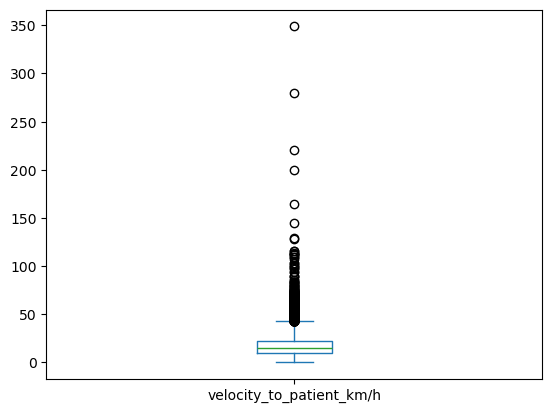

In [94]:
import matplotlib.pyplot as plt

df_dropped_na["velocity_to_patient_km/h"].plot(kind = "box")
# df_dropped_na["velocity_to_patient_km/h"].plot(kind = "bar")
plt.show()

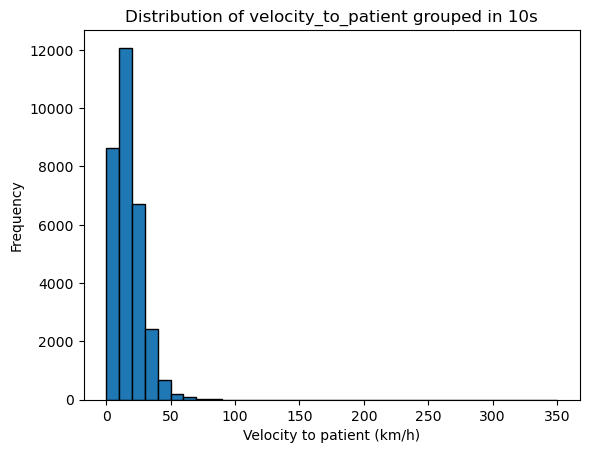

In [95]:
# Create bins of width 50 from 0 up to the max value
bins = range(0, int(df_dropped_na["velocity_to_patient_km/h"].max()) + 10, 10)

df_dropped_na["velocity_to_patient_km/h"].plot(kind="hist", bins=bins, edgecolor="black")

plt.xlabel("Velocity to patient (km/h)")
plt.ylabel("Frequency")
plt.title("Distribution of velocity_to_patient grouped in 10s")
plt.show()

Most of the velocities were between 0 to 50km/h